# Lab 1 — Tokenization & Embeddings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/angeloziletti/nlp-cas-dsmh/blob/main/notebooks/lab1_tokenization_embeddings.ipynb)

**This notebook is the lecture.** Instead of slides, we learn by running code and looking carefully at what comes out.

**How to use it**
- Run each cell in order — `Shift + Enter`, or the ▶ button on the left.
- Read the output *and* the explanation around it. We discuss every result together.
- Cells marked **🔧 YOUR TURN** are for you: change one value, re-run, see what happens.
- Nothing here can break. If a cell errors, just run it again or ask.

**By the end of this notebook you will understand, hands-on:**
1. **Tokenization** — how text is broken into pieces a model can read
2. **Embeddings** — how those pieces become numbers that capture *meaning*
3. **Semantic search** — finding text by meaning, not by keywords
4. **Context** — why modern models understand a word differently in different sentences

*All data in this lab is synthetic or public. No real patient data is ever used — that is a rule we will come back to later in the course.*

## Setup

Run the next two cells once. The first installs two libraries; the second loads everything we need, including the course datasets. The first run takes a minute or two — models are downloading in the background.

> **Running locally instead of Colab?** See the [README](https://github.com/angeloziletti/nlp-cas-dsmh#option-b--local-install) for a `conda` or `pip` install. With a local environment the `!pip install` cell below is a no-op — safe to run anyway.

In [1]:
!pip install -q sentence-transformers transformers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from transformers import AutoTokenizer, AutoModel, logging

logging.set_verbosity_error()  # keep the output clean

# --- Course data lives in the GitHub repo ---
BASE_URL = "https://raw.githubusercontent.com/angeloziletti/nlp-cas-dsmh/main/data/"

icd10 = pd.read_csv(BASE_URL + "icd10_sample.csv")
sentences = pd.read_csv(BASE_URL + "clinical_sentences.csv")
print(f"Loaded {len(icd10)} ICD-10 codes and {len(sentences)} clinical sentences.")

Loaded 300 ICD-10 codes and 2500 clinical sentences.


---
## Part 1 — Tokenization: how text becomes pieces

A language model never sees *words*. Before anything else, text is chopped into **tokens** — small pieces, each with an ID number. This step is called **tokenization**.

Common words are usually one token each. Let's check.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

for word in ["heart", "patient", "hospital", "fever", "blood"]:
    print(f"{word!r:12s} ->  {tokenizer.tokenize(word)}")

'heart'      ->  ['heart']
'patient'    ->  ['patient']
'hospital'   ->  ['hospital']
'fever'      ->  ['fever']
'blood'      ->  ['blood']


Every common word above became a **single token**. Now watch what happens with medical vocabulary.

In [4]:
for term in ["pneumonia", "myocardial", "infarction", "electrocardiogram",
             "gastroenteritis", "acetaminophen", "hepatosplenomegaly"]:
    pieces = tokenizer.tokenize(term)
    print(f"{term!r:22s} ->  {pieces}   ({len(pieces)} tokens)")

'pneumonia'            ->  ['pneumonia']   (1 tokens)
'myocardial'           ->  ['my', '##oca', '##rdial']   (3 tokens)
'infarction'           ->  ['in', '##far', '##ction']   (3 tokens)
'electrocardiogram'    ->  ['electro', '##card', '##io', '##gram']   (4 tokens)
'gastroenteritis'      ->  ['gas', '##tro', '##enter', '##itis']   (4 tokens)
'acetaminophen'        ->  ['ace', '##tam', '##ino', '##ph', '##en']   (5 tokens)
'hepatosplenomegaly'   ->  ['he', '##pa', '##tos', '##ple', '##no', '##me', '##gal', '##y']   (8 tokens)


Notice two things:

- Long or rare medical words get **split into sub-word pieces**. `electrocardiogram` becomes `electro` + `##card` + `##io` + `##gram`.
- The `##` prefix means *"this piece continues the previous one"* — it is not a new word.

**Why does this matter in healthcare?** Medical language is full of long, rare, technical terms. They fragment into many tokens. That has two consequences we will see later: models have a limited **context window** (measured in tokens), and commercial APIs **charge per token**. Dense clinical text costs more tokens than ordinary text.

In [5]:
# 🔧 YOUR TURN: type any medical term (or your own name) and run this cell.
my_term = "tachycardia"

print(f"{my_term!r} splits into: {tokenizer.tokenize(my_term)}")

'tachycardia' splits into: ['ta', '##chy', '##card', '##ia']


Let's make the token-count point concrete on a short clinical note.

In [6]:
clinical_note = """62-year-old male admitted with acute shortness of breath and chest pain.
History of hypertension, type 2 diabetes, and a myocardial infarction in 2019.
Current medications include aspirin and metoprolol. Examination revealed bibasilar
crackles. Assessment: rule out acute coronary syndrome versus heart failure
exacerbation. Plan: admit for monitoring, serial troponins, and echocardiography."""

n_words = len(clinical_note.split())
n_tokens = len(tokenizer.tokenize(clinical_note))
print(f"Words:  {n_words}")
print(f"Tokens: {n_tokens}")
print(f"Ratio:  {n_tokens / n_words:.2f} tokens per word")

Words:  51
Tokens: 91
Ratio:  1.78 tokens per word


Ordinary English runs around 1.3 tokens per word. Clinical text runs higher — the medical terms fragment. Keep this in mind: **"how long is this text" really means "how many tokens"**, and that is what limits and prices every model.

---
## Part 2 — Embeddings: turning pieces into meaning

Tokens still have no *meaning* — they are just IDs. The next step gives text meaning by turning it into a **vector**: a list of numbers that places the text in a "meaning space".

The key property: **text with similar meaning gets similar numbers**.

We use a model trained on biomedical text. Loading it takes a moment.

In [7]:
embedder = SentenceTransformer("NeuML/pubmedbert-base-embeddings")

vec = embedder.encode("myocardial infarction")
print("The phrase 'myocardial infarction' as the model sees it:")
print(f"  vector length: {len(vec)} numbers")
print(f"  first 8 numbers: {np.round(vec[:8], 3)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

The phrase 'myocardial infarction' as the model sees it:
  vector length: 768 numbers
  first 8 numbers: [-1.417  0.989  0.272 -0.726 -0.037  1.271  0.105 -0.341]


That list of 768 numbers *is* the phrase, to the model. On its own it means nothing — its power comes from **comparison**. Two pieces of text are similar in meaning if their vectors point in a similar direction. The standard measure for this is **cosine similarity**: 1.0 = identical direction, 0.0 = unrelated.

In [8]:
def similarity(a, b):
    va, vb = embedder.encode([a, b])
    return float(np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb)))

anchor = "heart attack"
for term in ["myocardial infarction", "MI", "chest pain", "cardiac arrest",
             "bone fracture", "x-ray", "banana"]:
    line = f"  '{anchor}'  vs  '{term}'"
    print(line.ljust(46) + f"{similarity(anchor, term):.3f}")

  'heart attack'  vs  'myocardial infarction' 0.558
  'heart attack'  vs  'MI'                    0.464
  'heart attack'  vs  'chest pain'            0.401
  'heart attack'  vs  'cardiac arrest'        0.463
  'heart attack'  vs  'bone fracture'         0.196
  'heart attack'  vs  'x-ray'                 0.134
  'heart attack'  vs  'banana'                0.120


Read that ranking top to bottom — it is exactly what a clinician would expect:

- **Synonyms** score highest: `myocardial infarction`, `MI` (the abbreviation), `cardiac arrest`.
- **Related** concepts score in the middle: `chest pain` is a symptom, not a synonym.
- **Different body system** scores low: `bone fracture`, `x-ray`.
- **Unrelated** scores lowest: `banana`.

The model was never given a medical dictionary. It learned these relationships from the way the words are used across millions of biomedical texts.

> **One important detail.** We deliberately use a *medical* embedding model. A general-purpose model — trained mostly on web text — scores `heart attack` vs `MI` at only about **0.15**, because on the web "MI" usually means the US state of Michigan. **In healthcare, the choice of model matters.**

In [9]:
# 🔧 YOUR TURN: pick any two words or phrases and measure how close they are.
term_a = "shortness of breath"
term_b = "dyspnea"

print(f"similarity = {similarity(term_a, term_b):.3f}")

similarity = 0.528


---
## Part 3 — Semantic search: finding meaning, not keywords

Ordinary search matches **words**. If you search clinical notes for "breathing", you miss every note that says "dyspnea" or "respiratory distress" instead.

**Semantic search** matches **meaning**. The idea is simple:
1. Turn every sentence in your collection into a vector (done once).
2. Turn the search query into a vector.
3. Return the sentences whose vectors are closest to the query's.

First, embed every clinical sentence in our collection. This is a one-off step — encoding a few thousand sentences takes about a minute.

In [10]:
corpus = sentences["sentence"].tolist()
corpus_vectors = embedder.encode(corpus, show_progress_bar=True)
print(f"Embedded {len(corpus)} clinical sentences — each is now a {corpus_vectors.shape[1]}-number vector.")

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embedded 2500 clinical sentences — each is now a 768-number vector.


In [11]:
def search(query, top_k=5):
    qv = embedder.encode(query)
    sims = corpus_vectors @ qv / (np.linalg.norm(corpus_vectors, axis=1) * np.linalg.norm(qv))
    for rank, i in enumerate(np.argsort(sims)[::-1][:top_k], 1):
        print(f"{rank}. ({sims[i]:.3f})  {corpus[i]}")

search("patient having difficulty breathing")

1. (0.615)  Hospital Course: The patient presented with increased cough and a drop in lung function during a routine out-patient visit and was diagnosed with CF.
2. (0.599)  The patient had a history of dysphonia and a recent complaint of slight dyspnea.
3. (0.566)  Condition at Discharge: The patient was alert and breathing comfortably without any signs of respiratory distress or pain.
4. (0.564)  The patient experienced recurrent episodes of non-ventilation due to tracheal pressure, which improved with repositioning of the endotracheal tube.
5. (0.564)  The patient also reported dyspnea under moderate stress.


Look at the results: the top matches are about breathing problems — but several of them **do not contain the word "breathing" at all**. They were found through meaning (dyspnea, respiratory, oxygen), not through matching letters. That is the whole point of semantic search, and it is the engine behind the RAG system you will build later in the course.

In [12]:
# 🔧 YOUR TURN: search the clinical sentences for anything you like.
my_query = "signs of infection"

search(my_query)

1. (0.572)  During admission, no signs of local or systemic inflammation were noted.
2. (0.519)  She was instructed to monitor for any signs of infection, including fever or discharge at the surgical site.
3. (0.512)  The family was advised to monitor the drain for any signs of infection and to seek medical attention immediately if any problems arose.
4. (0.497)  Diagnostic Workup: Infectious disease was consulted for repeated fevers.
5. (0.491)  She was informed about the signs and symptoms of recurrence of illness and instructed to seek medical attention if those were observed.


---
## Part 4 — Seeing the meaning space

Each ICD-10 diagnosis description is a vector in 768-dimensional space — impossible to picture directly. But we can *flatten* it down to 2 dimensions and plot it. Nearby points = similar meaning.

We embed 300 ICD-10 codes drawn from six different body systems, then plot them.

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\angel\anaconda3\envs\nlp-cas-dsmh\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


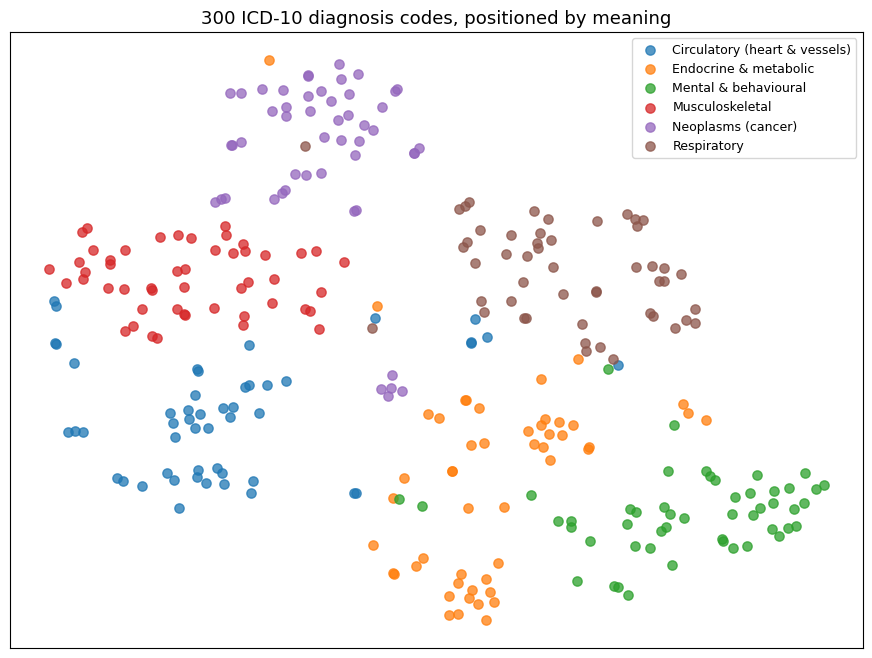

In [13]:
icd_vectors = embedder.encode(icd10["description"].tolist(), show_progress_bar=True)

coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(icd_vectors)

plt.figure(figsize=(11, 8))
for system in sorted(icd10["body_system"].unique()):
    mask = (icd10["body_system"] == system).values
    plt.scatter(coords[mask, 0], coords[mask, 1], label=system, s=45, alpha=0.75)
plt.legend(loc="best", fontsize=9)
plt.title("300 ICD-10 diagnosis codes, positioned by meaning", fontsize=13)
plt.xticks([]); plt.yticks([])
plt.show()

The colours separate into clear clusters — cardiac codes land together, respiratory codes land together, and so on.

**Nobody told the model what these categories are.** We never mentioned cardiology or psychiatry. The structure emerged purely from the language used in the code descriptions. This single picture is the whole idea of embeddings: *meaning becomes geometry.*

In [14]:
# 🔧 YOUR TURN: describe a diagnosis in plain words.
# We find the 5 ICD-10 codes whose meaning is closest — automated medical coding in miniature.
my_diagnosis = "irregular heartbeat"

qv = embedder.encode(my_diagnosis)
sims = icd_vectors @ qv / (np.linalg.norm(icd_vectors, axis=1) * np.linalg.norm(qv))
for i in np.argsort(sims)[::-1][:5]:
    print(f"  ({sims[i]:.3f})  {icd10['code'].iloc[i]}  -  {icd10['description'].iloc[i]}")

  (0.429)  I253  -  Aneurysm of heart
  (0.396)  I502  -  Systolic (congestive) heart failure
  (0.383)  I503  -  Diastolic (congestive) heart failure
  (0.365)  I5081  -  Right heart failure
  (0.353)  I492  -  Junctional premature depolarization


---
## Part 5 — Why context matters

The early word-embedding methods (word2vec, 2013) had one fixed vector per word — *forever*. So the word **"discharge"** got a single vector, even though it means completely different things in:

- "the patient was given a **discharge** from the hospital" (going home)
- "purulent **discharge** from the wound" (fluid)

Modern Transformer models fixed this. They produce a vector for each word **in its sentence** — the same word gets different vectors in different contexts. Let's see it directly.

In [15]:
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")
bert.eval()

def word_in_context(sentence, word):
    enc = bert_tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        hidden = bert(**enc).last_hidden_state[0]
    word_id = bert_tokenizer.convert_tokens_to_ids(word)
    position = (enc["input_ids"][0] == word_id).nonzero()[0].item()
    return hidden[position].numpy()

def cos(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

s1 = "the patient was given a discharge from the hospital"
s2 = "the discharge summary was sent to the family doctor"
s3 = "there was purulent discharge from the infected wound"

v1 = word_in_context(s1, "discharge")
v2 = word_in_context(s2, "discharge")
v3 = word_in_context(s3, "discharge")

print("The SAME word 'discharge', seen in three different sentences:\n")
print(f"  leaving-hospital  vs  discharge-summary : {cos(v1, v2):.3f}   <- similar meaning")
print(f"  leaving-hospital  vs  wound-discharge   : {cos(v1, v3):.3f}   <- different meaning")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

The SAME word 'discharge', seen in three different sentences:

  leaving-hospital  vs  discharge-summary : 0.752   <- similar meaning
  leaving-hospital  vs  wound-discharge   : 0.584   <- different meaning


The two "leaving hospital" senses are closer to each other than either is to the "wound fluid" sense — even though it is the *identical word* every time. The model worked out the meaning **from the surrounding words**.

That mechanism is **attention**, the heart of the Transformer (covered in the history slides earlier in the course). It is also why modern models can read real clinical language, where meaning is spread across a whole sentence.

---
## Recap — what you just did

| Concept | What you saw |
|---|---|
| **Tokenization** | Text is split into tokens; medical words fragment into many pieces |
| **Embeddings** | Text becomes a vector; similar meaning → similar numbers |
| **Semantic search** | Finding text by meaning, even with no shared keywords |
| **Context** | The same word gets different vectors in different sentences |

These four ideas are the foundation for everything else in the course.

**Next:** instead of comparing and searching text, we make a model *generate* text — and we learn to control it with **prompts**. That is where clinical extraction, classification, and summarization begin.